## Notebook 6 — Figure 7 across SAVI binarization thresholds

Figure 7 (the 2×3 *vegetation response by predictor* panel, notebook 2 cell 13)
is built on the vegetation-response outcome, which binarizes the SAVI percent
difference (`effect_percent`) at **7 %**. This notebook reproduces the **entire
figure** at every cut-off from **0 % to 10 % in 1 % increments**, so the bar
heights, significance brackets, and stars can be inspected directly at each
threshold.

Companion to notebook 5 (which sweeps the summary statistics of Figs. 7 & 8);
here we redraw the full figure. Flow accumulation is binarized at the fixed
2 000-cell cut-off used in the paper, independent of the SAVI threshold.
Inputs come from `data/merged.csv`.

In [7]:
import sys as _sys
_sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations as _combinations
from scipy.stats import fisher_exact, chi2_contingency

from constants import (
    LENGTH_COLORS, SLOPE_COLORS, SOILDEV_COLORS,
    LF_COLORS, lf_order,
    TEXTURE_COLORS, texture_order,
    LBL_EFFECTIVE, LBL_INEFFECTIVE,
    FS, FS_SUP,
)
from plotting import _sig_stars

pd.set_option('display.max_columns', 50)

In [2]:
# ── Data + sweep configuration ───────────────────────────────────────────────
data = pd.read_csv('../data/merged.csv')

THRESHOLDS = list(range(0, 11))     # SAVI % difference cut-offs, 0 → 10 %
BASELINE_T = 7                      # value used in notebooks 1–2
FA_OPT     = 2000                   # fixed flow-accumulation cut-off (cells)

SENS_DIR = Path('../figures/sensitivity')
SENS_DIR.mkdir(parents=True, exist_ok=True)

_w = 0.25                           # bar half-width (matches notebook 2 cell 13)

# Fixed category labels (match the columns created in notebook 1).
long_lbl,  short_lbl   = 'Long (> 60 m)', 'Short (≤ 60 m)'
shallow_lbl, steep_lbl = 'Shallow (≤ 2%)', 'Steep (> 2%)'
bhorizon_lbl, nobhorizon_lbl = 'B horizon', 'No B horizon'
fa_high_lbl = f'High FA (≥ {FA_OPT/1000:.0f}k)'
fa_low_lbl  = f'Low FA (< {FA_OPT/1000:.0f}k)'

print(f"{len(data)} berm rows; sweeping thresholds {THRESHOLDS} (baseline = {BASELINE_T}%).")

775 berm rows; sweeping thresholds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] (baseline = 7%).


## Panel-draw helpers

Ported verbatim from notebook 2 cell 13 (the vegetation-response versions), so
each rendered figure is identical in construction to the published Figure 7 —
only the `Effective` binarization changes per threshold. Two-category panels use
two-sided Fisher's exact tests; multi-category panels use pairwise Fisher's exact
with Benjamini–Hochberg FDR correction (landform, texture) or a chi-square
omnibus in the title.

In [3]:
def _eff_two_cat_metrics(df_sub, group_col, cat_a, cat_b):
    '''Fisher exact for vegetation-response rate between two categories.'''
    d = df_sub.dropna(subset=[group_col, 'Effective']).copy()
    n_a = (d[group_col] == cat_a).sum()
    n_b = (d[group_col] == cat_b).sum()
    rows = {}
    for metric, pos_fn in [(LBL_EFFECTIVE,   lambda x: x['Effective'] == LBL_EFFECTIVE),
                           (LBL_INEFFECTIVE, lambda x: x['Effective'] == LBL_INEFFECTIVE)]:
        mask = pos_fn(d)
        c_a  = mask[d[group_col] == cat_a].sum()
        c_b  = mask[d[group_col] == cat_b].sum()
        p_a, p_b = c_a / n_a, c_b / n_b
        _, p_val = fisher_exact([[c_a, n_a - c_a], [c_b, n_b - c_b]])
        rows[metric] = {cat_a: p_a, cat_b: p_b, 'sig': _sig_stars(p_val)}
    return pd.DataFrame(rows).T


def _draw_eff_two_cat_panel(ax, m, cat_a, cat_b, colors, legend_title, title):
    outcomes = [LBL_EFFECTIVE, LBL_INEFFECTIVE]
    short    = ['Vegetation response', 'No vegetation response']
    x = np.arange(2)
    for cat, offset in [(cat_a, -_w/2), (cat_b, _w/2)]:
        vals = [m.loc[o, cat] for o in outcomes]
        ax.bar(x + offset, vals, _w, label=cat, color=colors[cat],
               edgecolor='black', linewidth=0.7)
    for i, o in enumerate(outcomes):
        sig = m.loc[o, 'sig']
        top = max(m.loc[o, cat_a], m.loc[o, cat_b]) + 0.03
        bh  = 0.015
        ax.plot([x[i]-_w/2, x[i]-_w/2, x[i]+_w/2, x[i]+_w/2],
                [top, top+bh, top+bh, top], lw=1, color='black')
        col = 'black' if sig != 'ns' else '#888888'
        ax.text(x[i], top+bh+0.005, sig, ha='center', va='bottom',
                fontsize=FS, color=col, fontweight='bold' if sig != 'ns' else 'normal')
    ax.set_xticks(x); ax.set_xticklabels(short)
    ax.set_ylabel('Proportion of berms')
    ax.set_title(f"{title}", fontsize=FS, loc='left', x=-0.05, y=1.05)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.legend(frameon=True, fontsize=FS, loc='upper right', bbox_to_anchor=(1, 1.05))
    sns.despine(ax=ax)


def _draw_eff_multi_cat_panel(ax, df_sub, group_col, cat_order, cat_colors, title, pairwise=False):
    '''Grouped bars: Response / No response x-axis, one bar per category.'''
    d = df_sub.dropna(subset=[group_col, 'Effective']).copy()
    cats   = [c for c in cat_order if c in d[group_col].unique()]
    n_cats = len(cats)
    bar_w  = _w
    _mc_w  = n_cats * bar_w
    offsets = np.linspace(-_mc_w/2 + bar_w/2, _mc_w/2 - bar_w/2, n_cats)
    outcomes = [LBL_EFFECTIVE, LBL_INEFFECTIVE]
    short    = ['Vegetation response', 'No vegetation response']
    x = np.arange(2)

    bars_data, ns_cat = {}, {}
    for cat in cats:
        sub = d[d[group_col] == cat]
        n   = len(sub)
        ns_cat[cat] = n
        bars_data[cat] = {
            LBL_EFFECTIVE:   (sub['Effective'] == LBL_EFFECTIVE).sum() / n,
            LBL_INEFFECTIVE: (sub['Effective'] == LBL_INEFFECTIVE).sum() / n,
        }

    ct_chi = pd.crosstab(d[group_col], d['Effective']).reindex(cats).dropna()
    _, p_chi, *_ = chi2_contingency(ct_chi)

    for cat, offset in zip(cats, offsets):
        for oi, outcome in enumerate(outcomes):
            ax.bar(x[oi] + offset, bars_data[cat][outcome], bar_w,
                   color=cat_colors.get(cat, '#aaaaaa'), edgecolor='black', linewidth=0.5,
                   label=cat if oi == 0 else '_nolegend_')

    bh = 0.025
    if pairwise:
        pair_list = list(_combinations(range(n_cats), 2))
        pair_list.sort(key=lambda p: abs(offsets[p[1]] - offsets[p[0]]))
        _raw = {}
        for oi, outcome in enumerate(outcomes):
            for ci, cj in pair_list:
                ca, cb = cats[ci], cats[cj]
                na, nb = ns_cat[ca], ns_cat[cb]
                ka = (d[d[group_col]==ca]['Effective'] == outcome).sum()
                kb = (d[d[group_col]==cb]['Effective'] == outcome).sum()
                _, p_pair = fisher_exact([[ka, na-ka], [kb, nb-kb]])
                _raw[(oi, ci, cj)] = p_pair
        _keys = list(_raw.keys()); _ps = np.array([_raw[k] for k in _keys])
        _m = len(_ps); _ord = np.argsort(_ps); _adj = np.empty(_m); _running = 1.0
        for _rank in range(_m - 1, -1, -1):
            _idx = _ord[_rank]
            _val = _ps[_idx] * _m / (_rank + 1)
            _running = min(_running, _val)
            _adj[_idx] = min(_running, 1.0)
        _padj = {k: _adj[i] for i, k in enumerate(_keys)}

        global_y_max = 0
        for oi, outcome in enumerate(outcomes):
            current_top = max(bars_data[cat][outcome] for cat in cats) + 0.03
            for ci, cj in pair_list:
                ca, cb = cats[ci], cats[cj]
                sig = _sig_stars(_padj[(oi, ci, cj)])
                x_left, x_right = x[oi] + offsets[ci], x[oi] + offsets[cj]
                y_base = max(bars_data[ca][outcome], bars_data[cb][outcome])
                y_start = max(y_base + 0.02, current_top)
                ax.plot([x_left, x_left, x_right, x_right],
                        [y_start, y_start+bh, y_start+bh, y_start],
                        lw=0.9, color='black' if sig != 'ns' else '#bbbbbb')
                col = 'black' if sig != 'ns' else '#aaaaaa'
                ax.text((x_left+x_right)/2, y_start+bh+0.003, sig, ha='center', va='bottom',
                        fontsize=FS, color=col, fontweight='bold' if sig != 'ns' else 'normal')
                current_top = y_start + bh + 0.025
            global_y_max = max(global_y_max, current_top)
    else:
        sig_overall = _sig_stars(p_chi)
        for oi in range(2):
            vals = [bars_data[cat][outcomes[oi]] for cat in cats]
            top  = max(vals) + 0.03
            ax.plot([x[oi]-_mc_w/2, x[oi]-_mc_w/2, x[oi]+_mc_w/2, x[oi]+_mc_w/2],
                    [top, top+bh, top+bh, top], lw=1, color='black')
            col = 'black' if sig_overall != 'ns' else '#888888'
            ax.text(x[oi], top+bh+0.005, sig_overall, ha='center', va='bottom',
                    fontsize=FS, color=col, fontweight='bold' if sig_overall != 'ns' else 'normal')

    ax.set_xticks(x); ax.set_xticklabels(short)
    ax.set_ylabel('Proportion of berms')
    ax.set_title(f"{title}", fontsize=FS, loc='left', x=-0.05, y=1.05)
    ax.set_ylim(0, 1.1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.legend(frameon=True, fontsize=FS, loc='upper right', bbox_to_anchor=(1, 1.05))
    sns.despine(ax=ax)

## Reusable Figure 7 builder

`draw_fig7()` recomputes the vegetation-response label at an arbitrary threshold
and assembles the full 2×3 figure using the helpers above.

In [4]:
def draw_fig7(df, t, save=False):
    '''Reproduce the full 2×3 Figure 7 at SAVI threshold *t*. Returns the figure.'''
    d = df.copy()
    d['Effective'] = np.where(d['effect_percent'] > t, LBL_EFFECTIVE, LBL_INEFFECTIVE)
    d['FA_Class']  = np.where(d['FA_30_max'] >= FA_OPT, fa_high_lbl, fa_low_lbl)

    # Two-category metrics
    eff_len_m      = _eff_two_cat_metrics(d, 'Berm_Length_Class', long_lbl, short_lbl)
    eff_slope_m    = _eff_two_cat_metrics(d, 'Slope_Class', shallow_lbl, steep_lbl)
    eff_bhorizon_m = _eff_two_cat_metrics(d, 'Soil_Development', bhorizon_lbl, nobhorizon_lbl)
    eff_fa_m       = _eff_two_cat_metrics(d, 'FA_Class', fa_high_lbl, fa_low_lbl)

    EFF_COLORS_LEN   = {long_lbl:  LENGTH_COLORS['Long (> 60 m)'],
                        short_lbl: LENGTH_COLORS['Short (≤ 60 m)']}
    EFF_COLORS_SLOPE = {shallow_lbl: SLOPE_COLORS['Shallow (≤ 2%)'],
                        steep_lbl:   SLOPE_COLORS['Steep (> 2%)']}
    EFF_COLORS_BH    = {bhorizon_lbl:   SOILDEV_COLORS['B horizon'],
                        nobhorizon_lbl: SOILDEV_COLORS['No B horizon']}
    FA_COLORS        = {fa_high_lbl: '#4a90d9', fa_low_lbl: '#a8c8f0'}

    # Texture: classes with n > 100 (matches the figure)
    tex_counts     = d['Texture'].value_counts()
    tex_valid      = tex_counts[tex_counts > 100].index
    tex_order_eff  = [tx for tx in texture_order if tx in tex_valid]
    tex_colors_eff = {tx: TEXTURE_COLORS.get(tx, '#aaaaaa') for tx in tex_order_eff}

    plt.rcParams.update({'font.size': 12, 'axes.titlesize': 12, 'axes.labelsize': 12,
                         'xtick.labelsize': 12, 'ytick.labelsize': 12})
    fig, axes = plt.subplots(2, 3, figsize=(20, 11), sharey=True)
    plt.subplots_adjust(wspace=0.3, hspace=0.4)

    _draw_eff_two_cat_panel(axes[0, 0], eff_len_m, long_lbl, short_lbl,
                            EFF_COLORS_LEN, 'Length class', 'A  |  Berm length')
    _draw_eff_two_cat_panel(axes[0, 1], eff_slope_m, shallow_lbl, steep_lbl,
                            EFF_COLORS_SLOPE, 'Slope class', 'B  |  Slope class')
    _draw_eff_multi_cat_panel(axes[0, 2], d, 'Landform', lf_order, LF_COLORS,
                              'C  |  Landform', pairwise=True)
    _draw_eff_multi_cat_panel(axes[1, 0], d, 'Texture', tex_order_eff, tex_colors_eff,
                              'D  |  Soil texture', pairwise=True)
    _draw_eff_two_cat_panel(axes[1, 1], eff_bhorizon_m, bhorizon_lbl, nobhorizon_lbl,
                            EFF_COLORS_BH, 'Soil development', 'E  |  B horizon presence')
    _draw_eff_two_cat_panel(axes[1, 2], eff_fa_m, fa_high_lbl, fa_low_lbl,
                            FA_COLORS, 'Flow accumulation', 'F  |  Flow accumulation')

    for _ax in axes[:, 1:].flat:
        _ax.set_ylabel('')

    fig.suptitle(f"Figure 7 — vegetation response by predictor  (threshold > {t}%)",
                 fontsize=FS_SUP, y=1.01, fontweight='bold')

    if save:
        fig.savefig(SENS_DIR / f"fig7_threshold_{t:02d}pct.png", dpi=200, bbox_inches='tight')
    return fig

## Sanity check — Figure 7 at the baseline 7 % threshold

Should match the published Figure 7: vegetation response significantly associated
with slope class, landform, and soil texture; steep-slope and flood-plain berms
show the highest response rates.

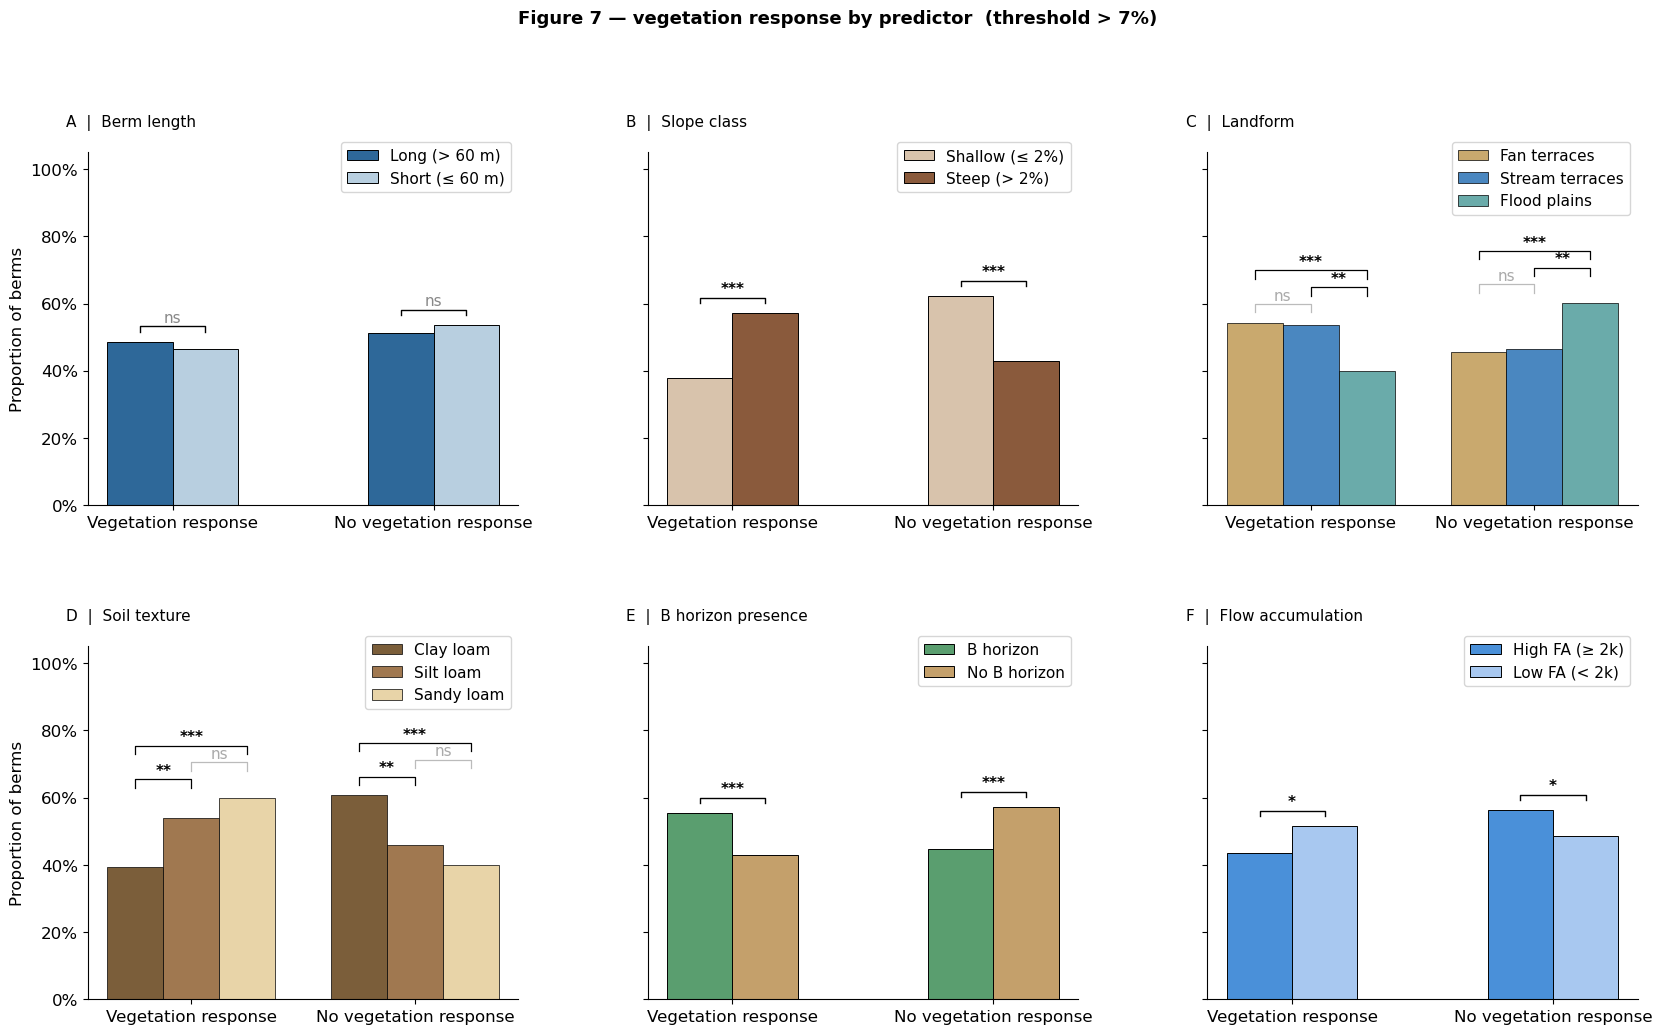

In [5]:
draw_fig7(data, BASELINE_T)
plt.show()

## Figure 7 rendered at every threshold

The full 2×3 figure regenerated for each cut-off from 0 % to 10 %. Each render is
saved to `figures/sensitivity/fig7_threshold_XXpct.png`. Compare the significance
stars across thresholds: the slope, landform, and texture associations persist,
while flow accumulation moves in and out of significance (see notebook 5 for the
per-predictor p-value trajectories).

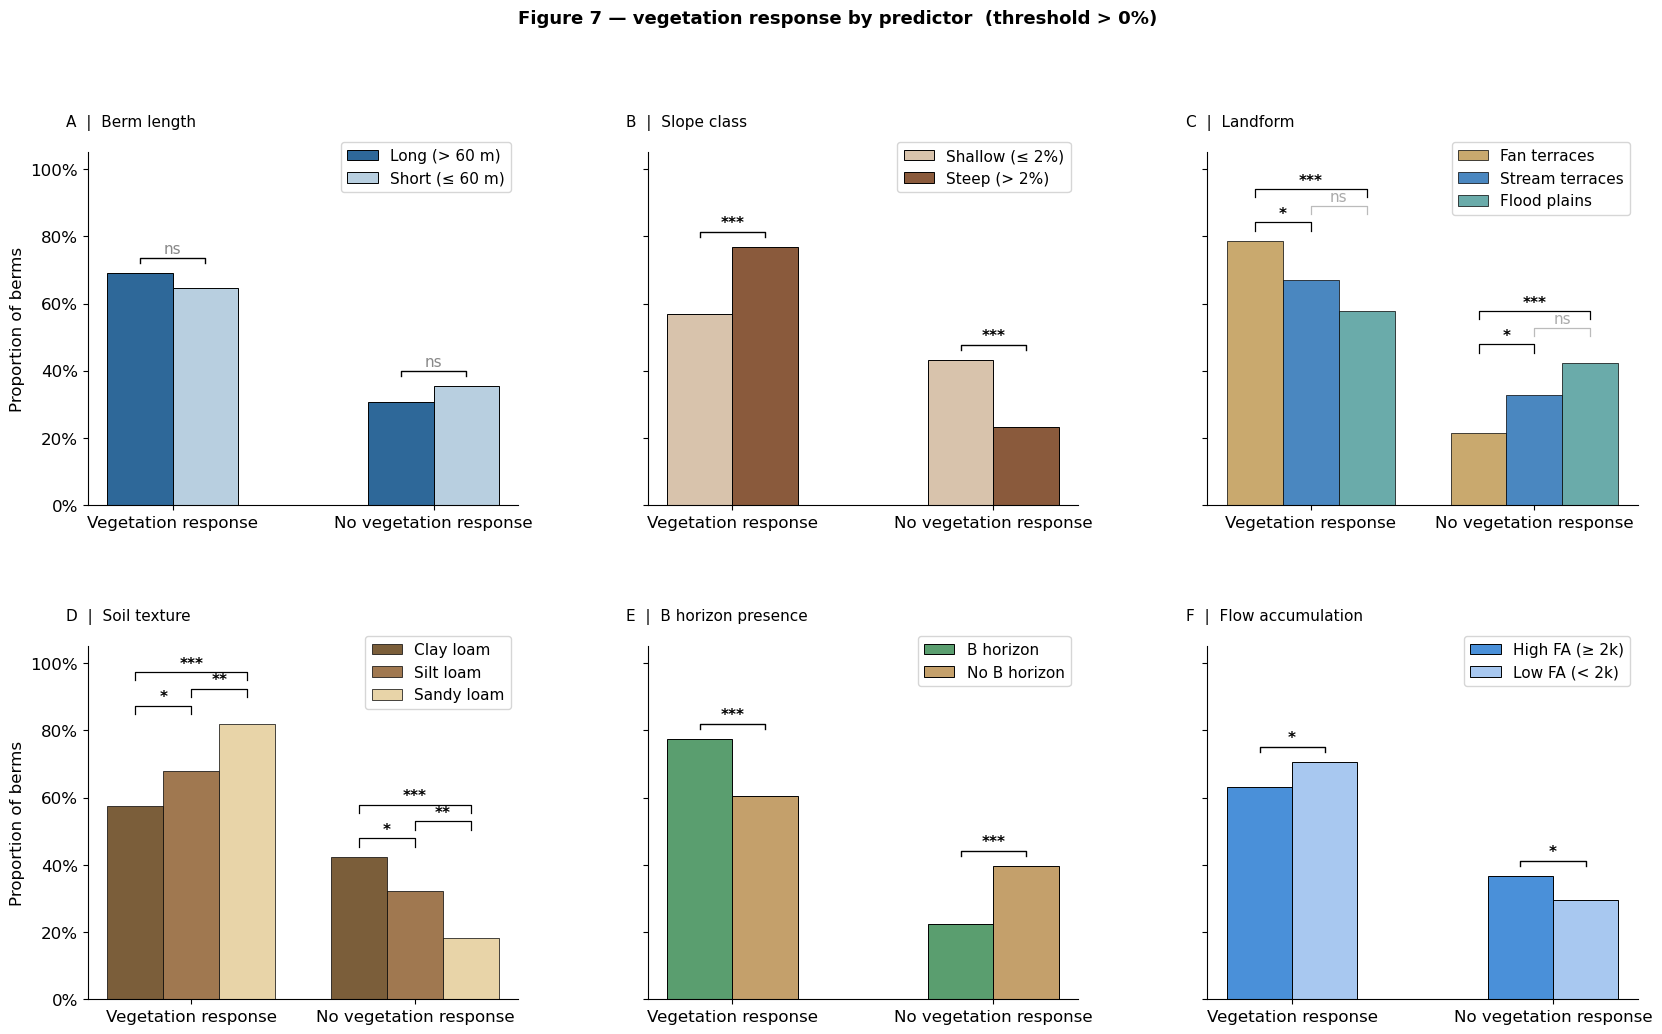

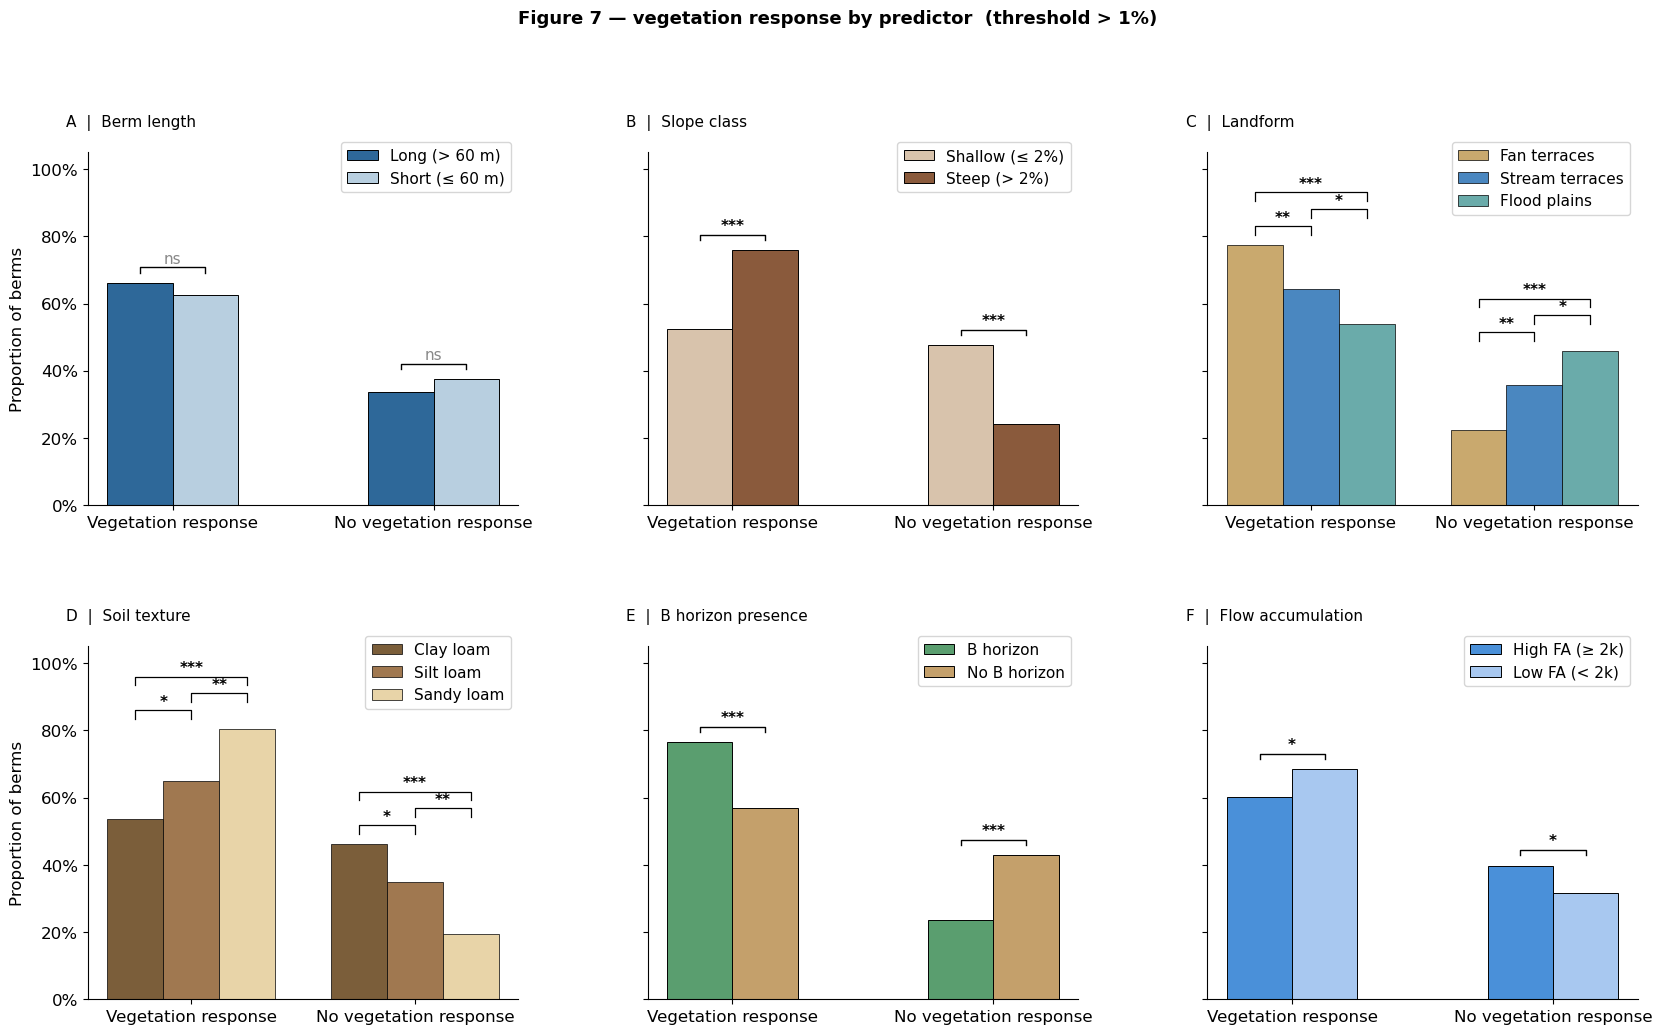

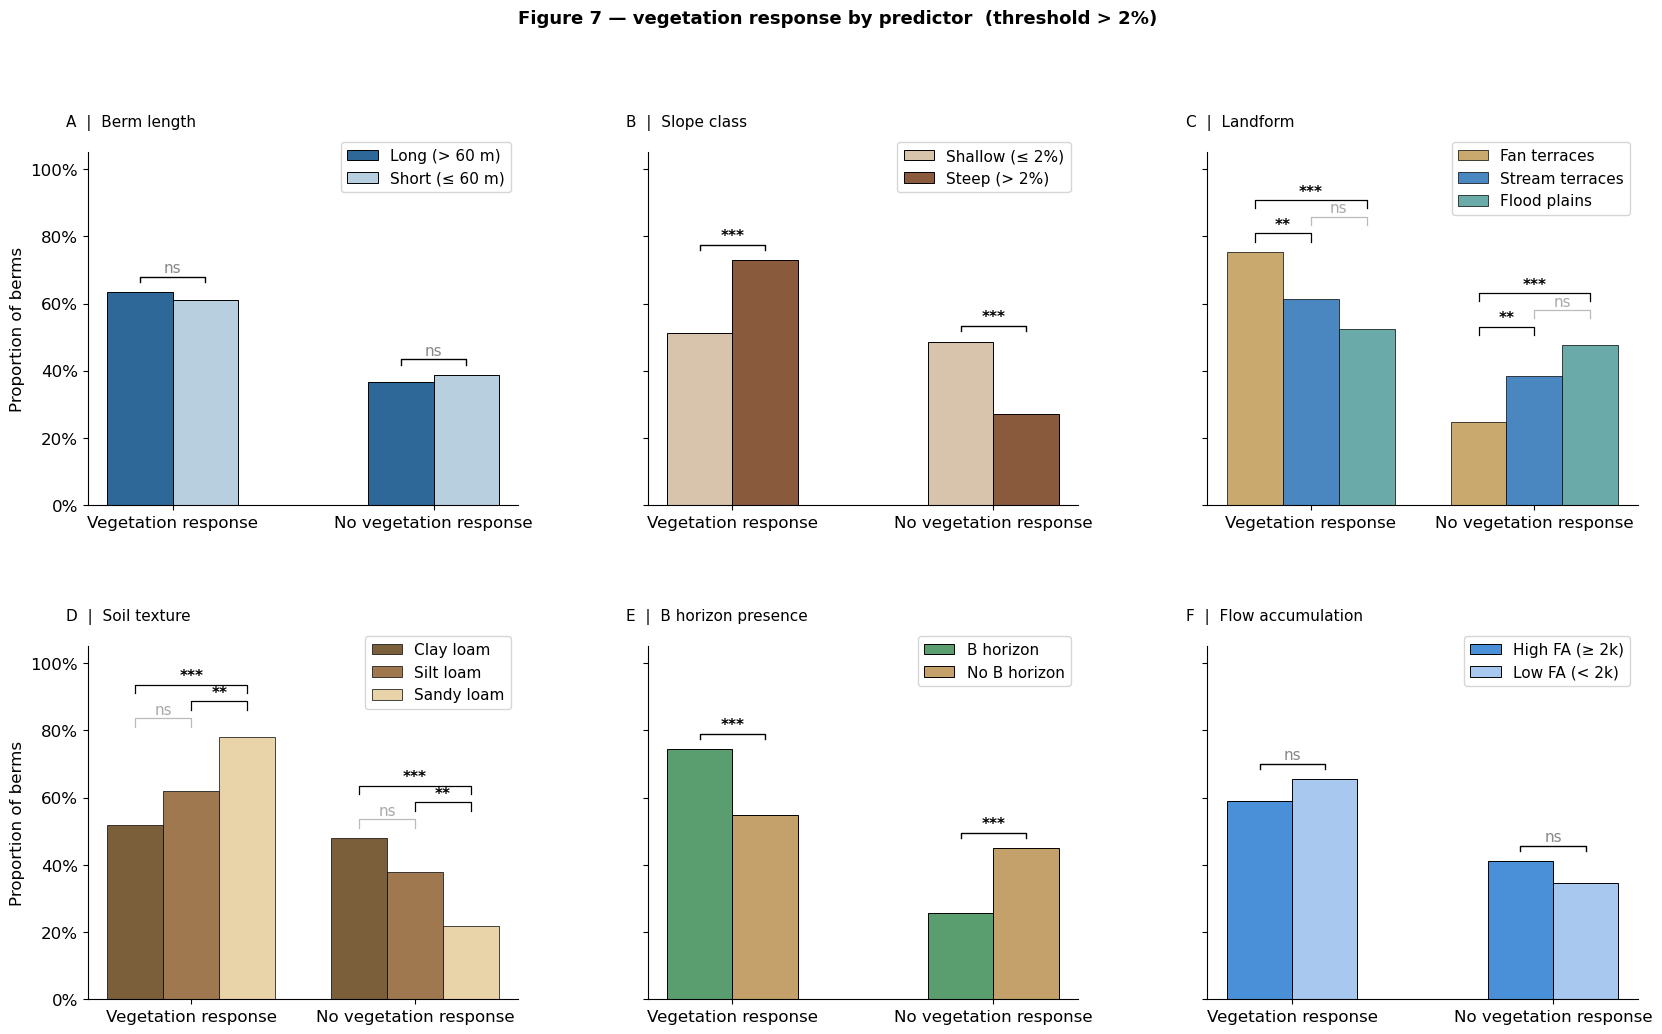

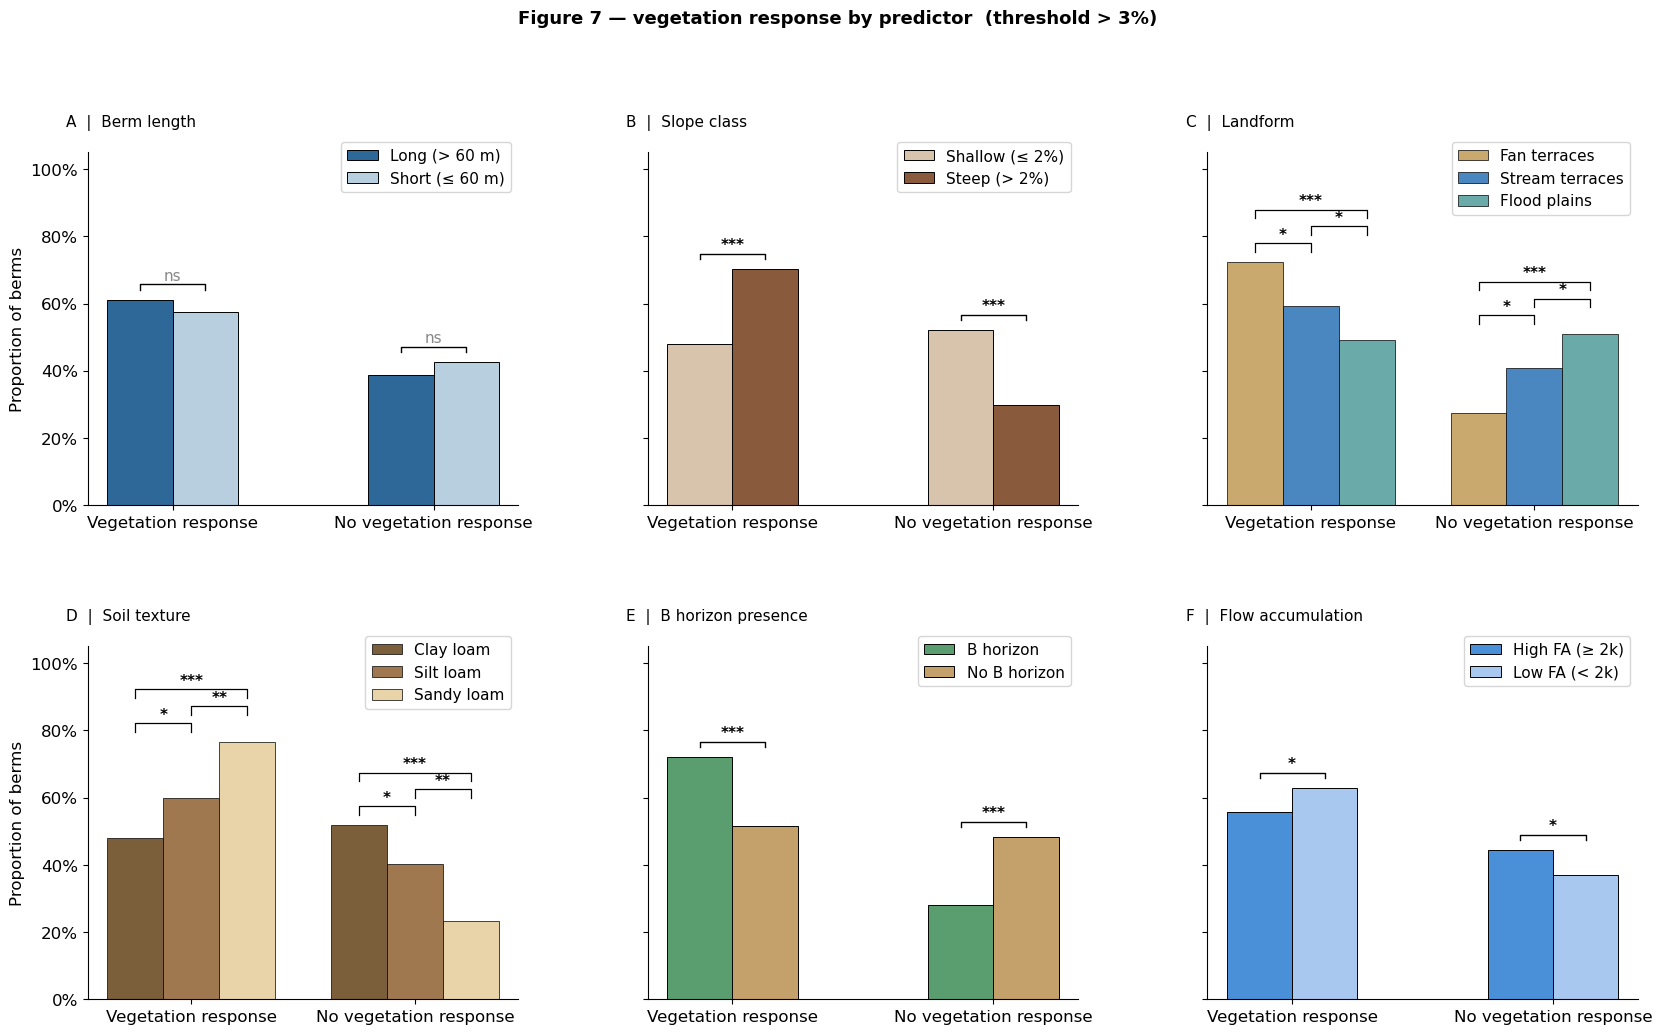

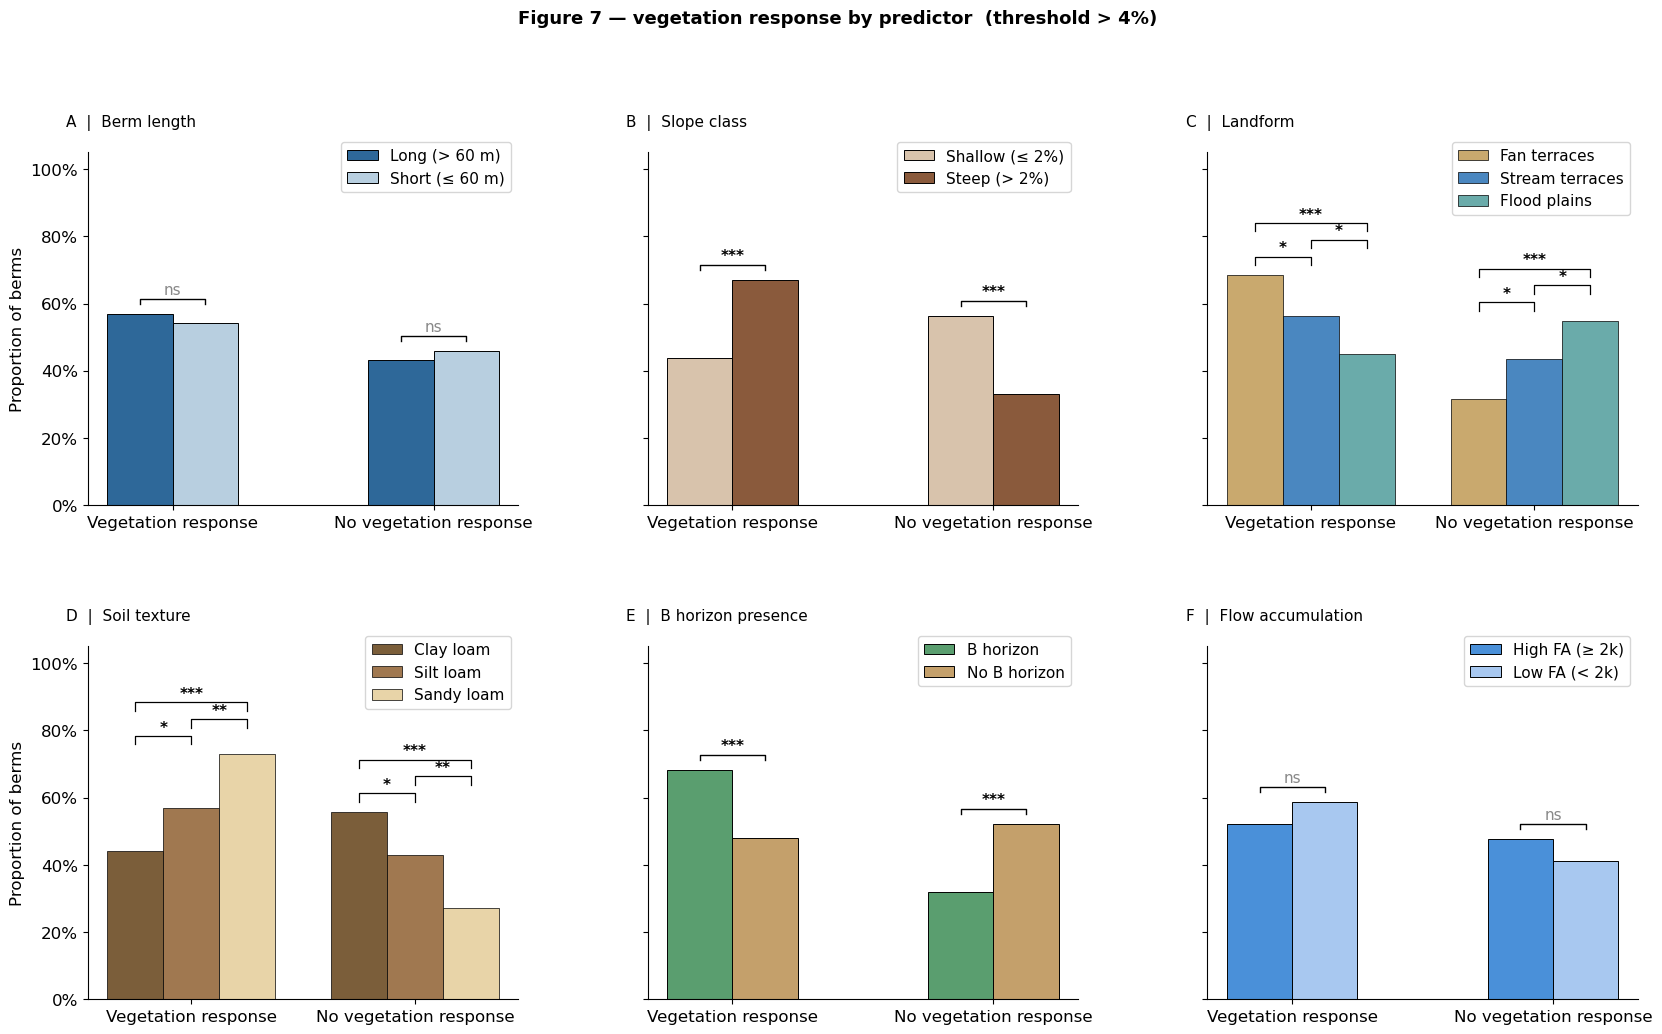

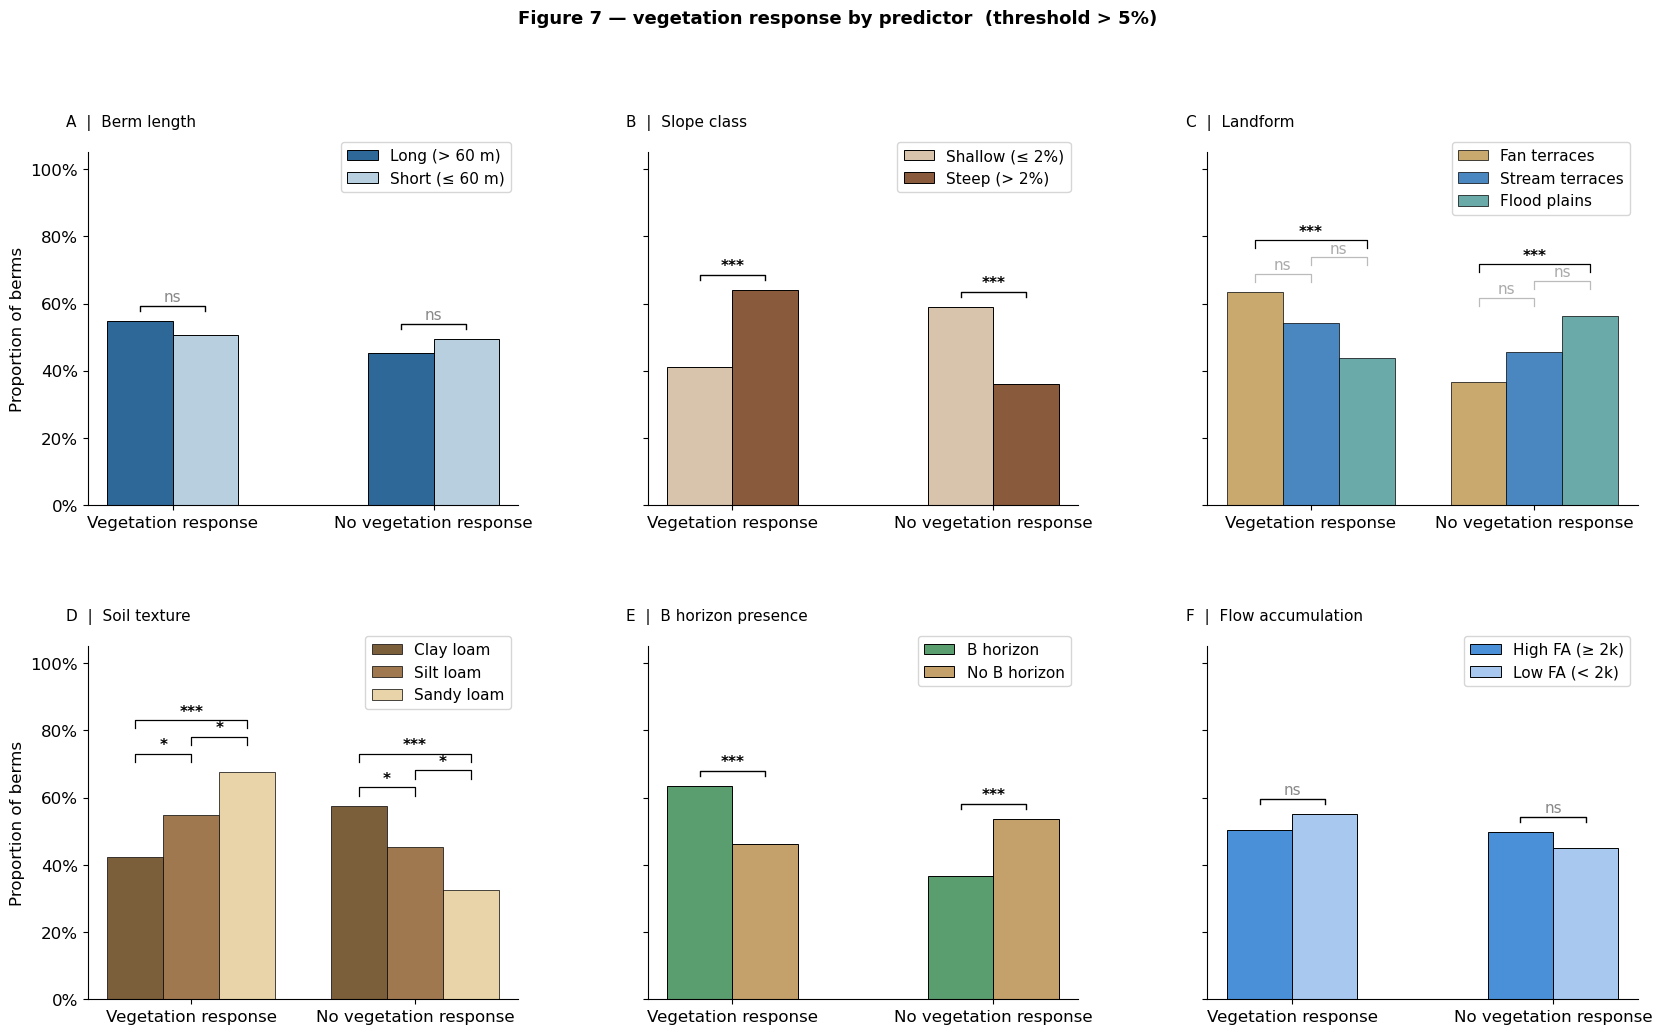

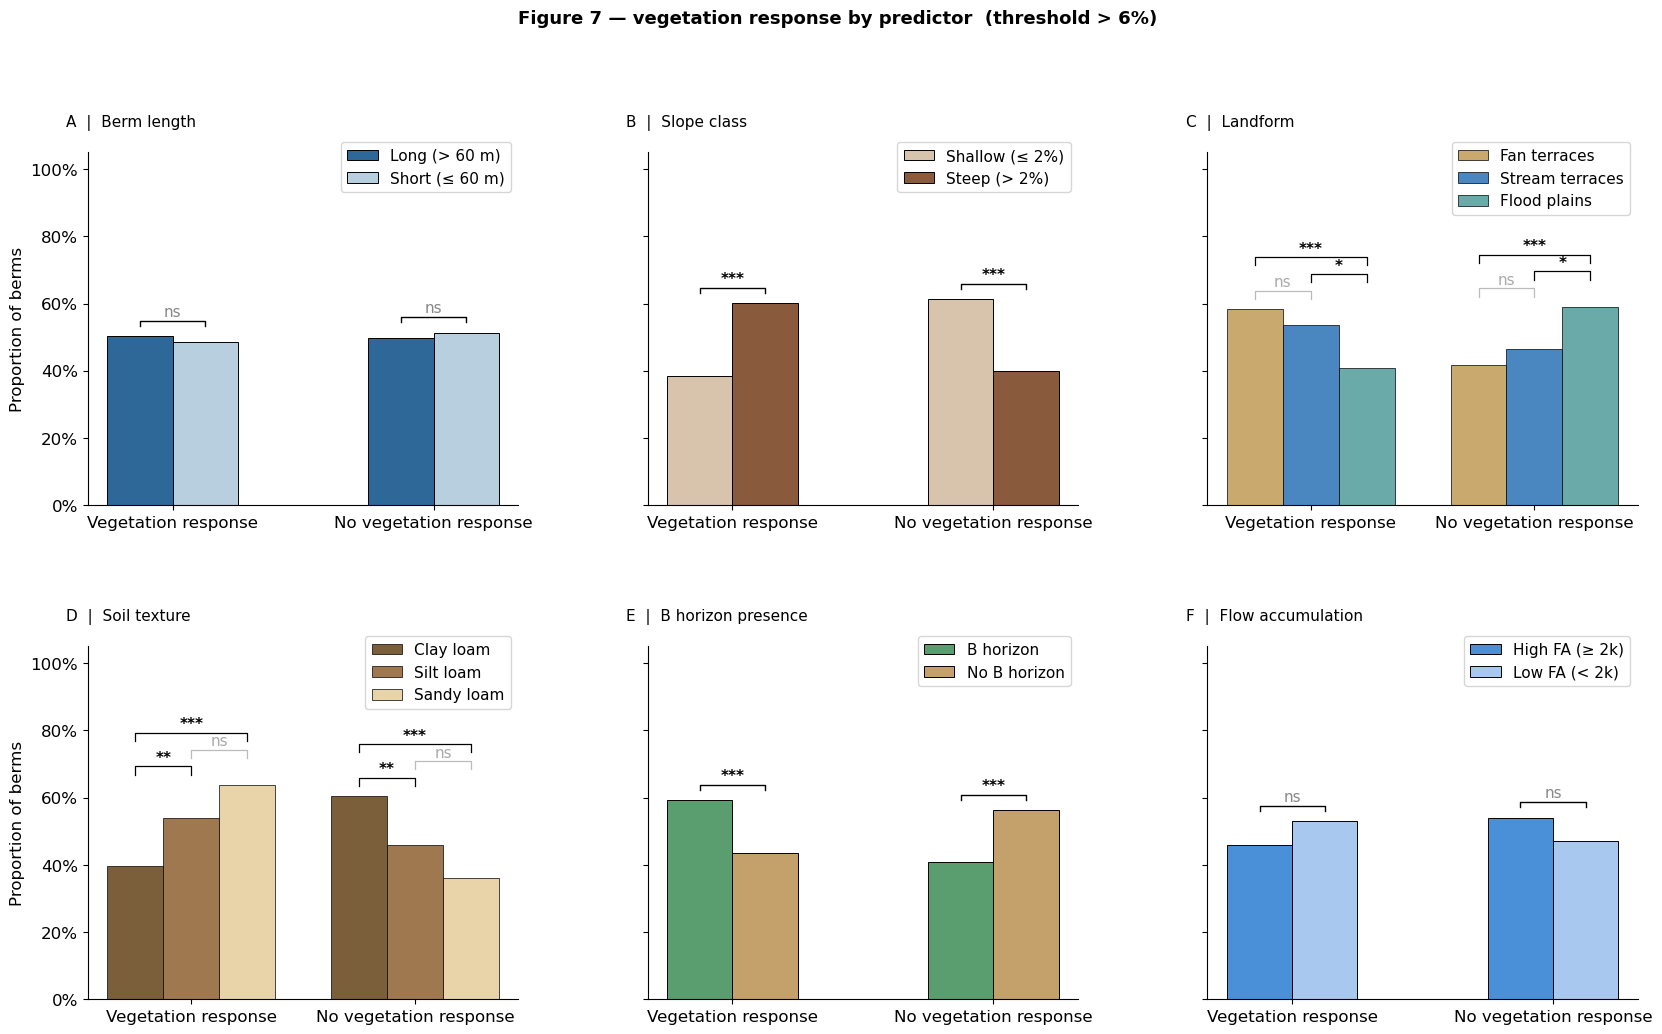

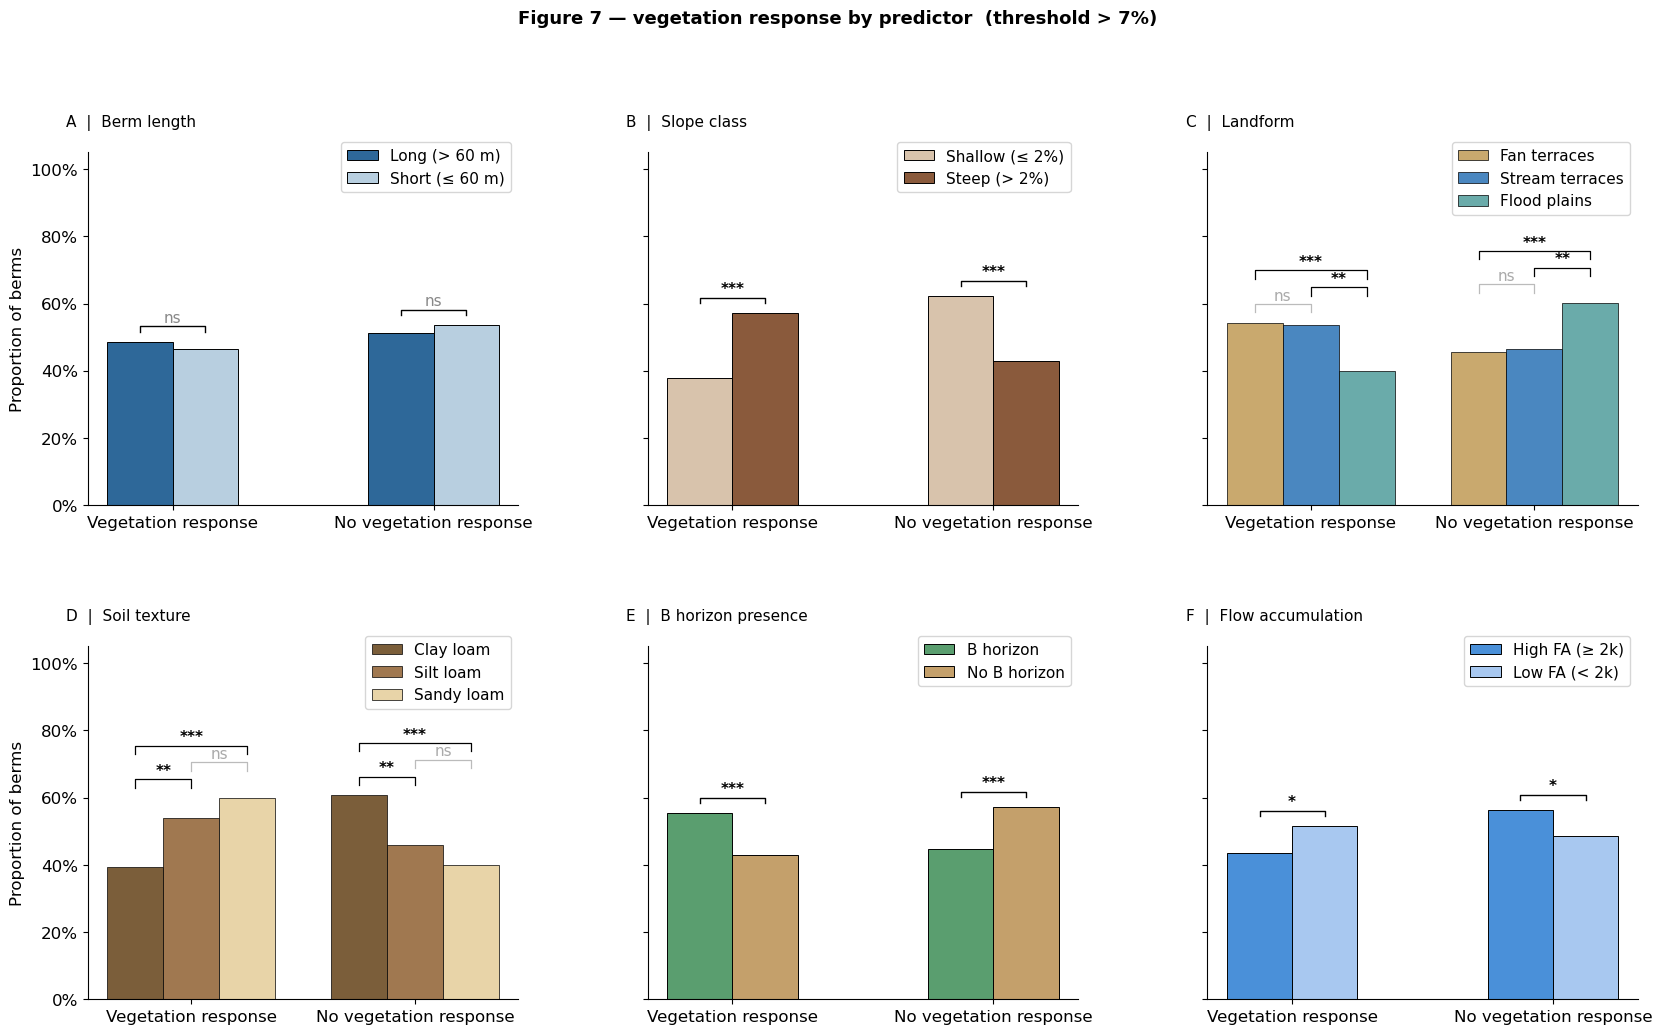

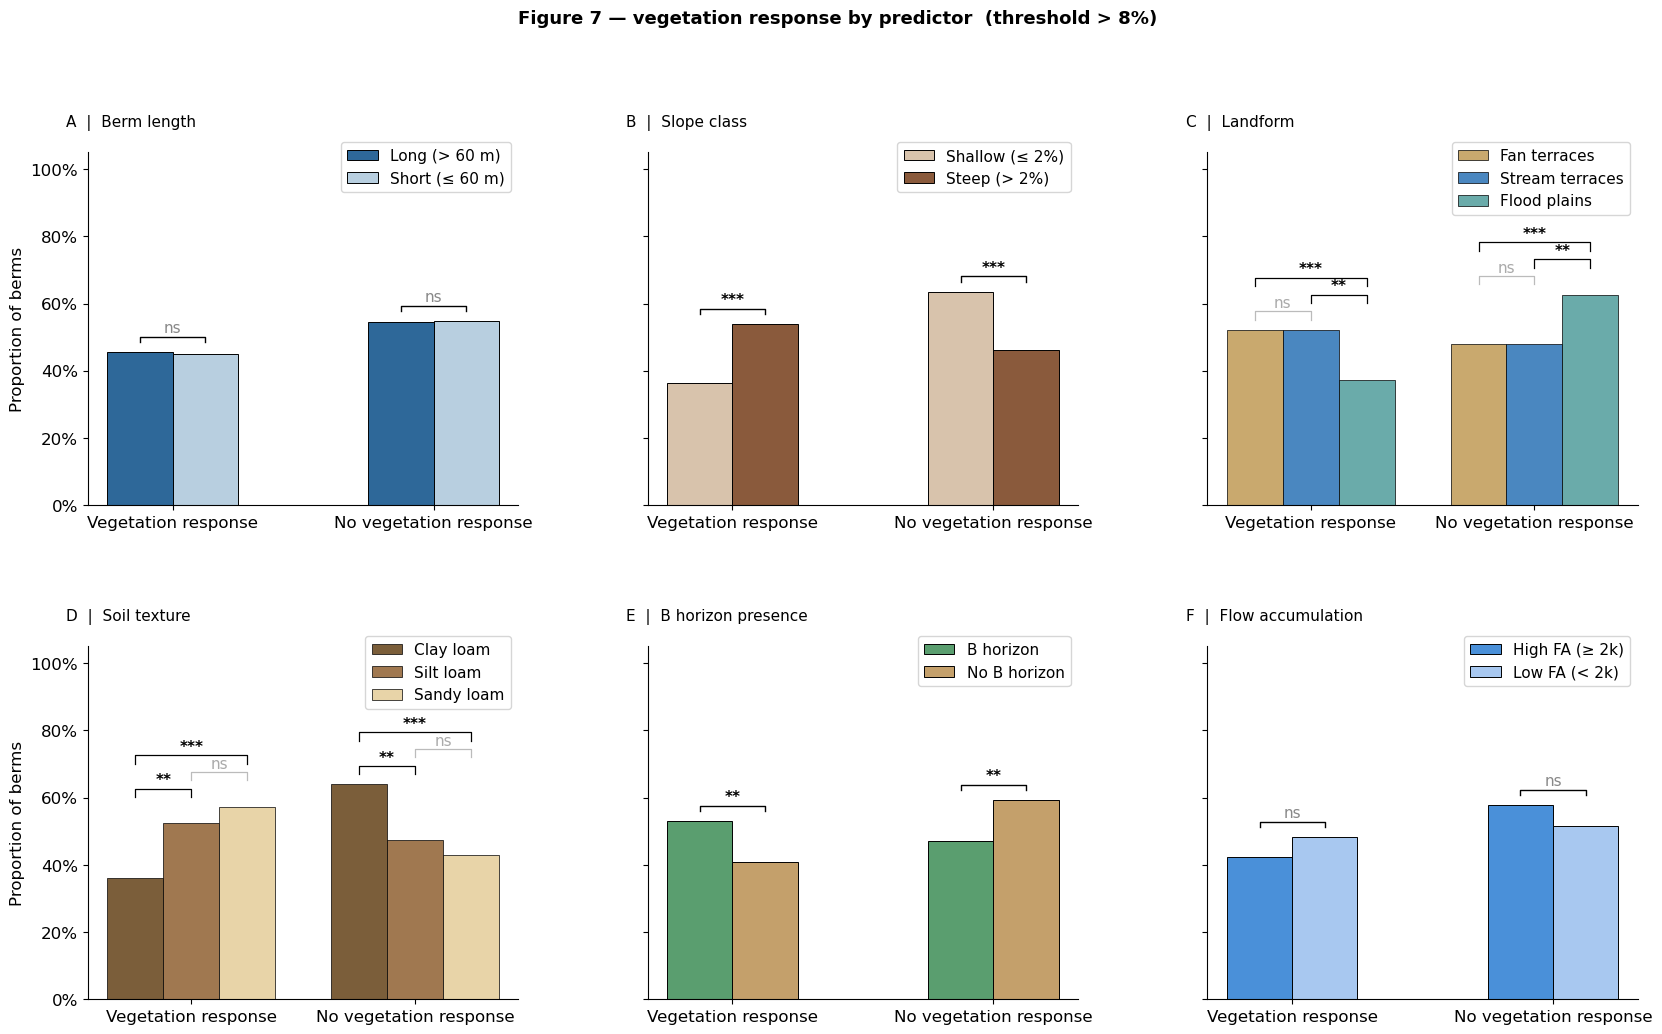

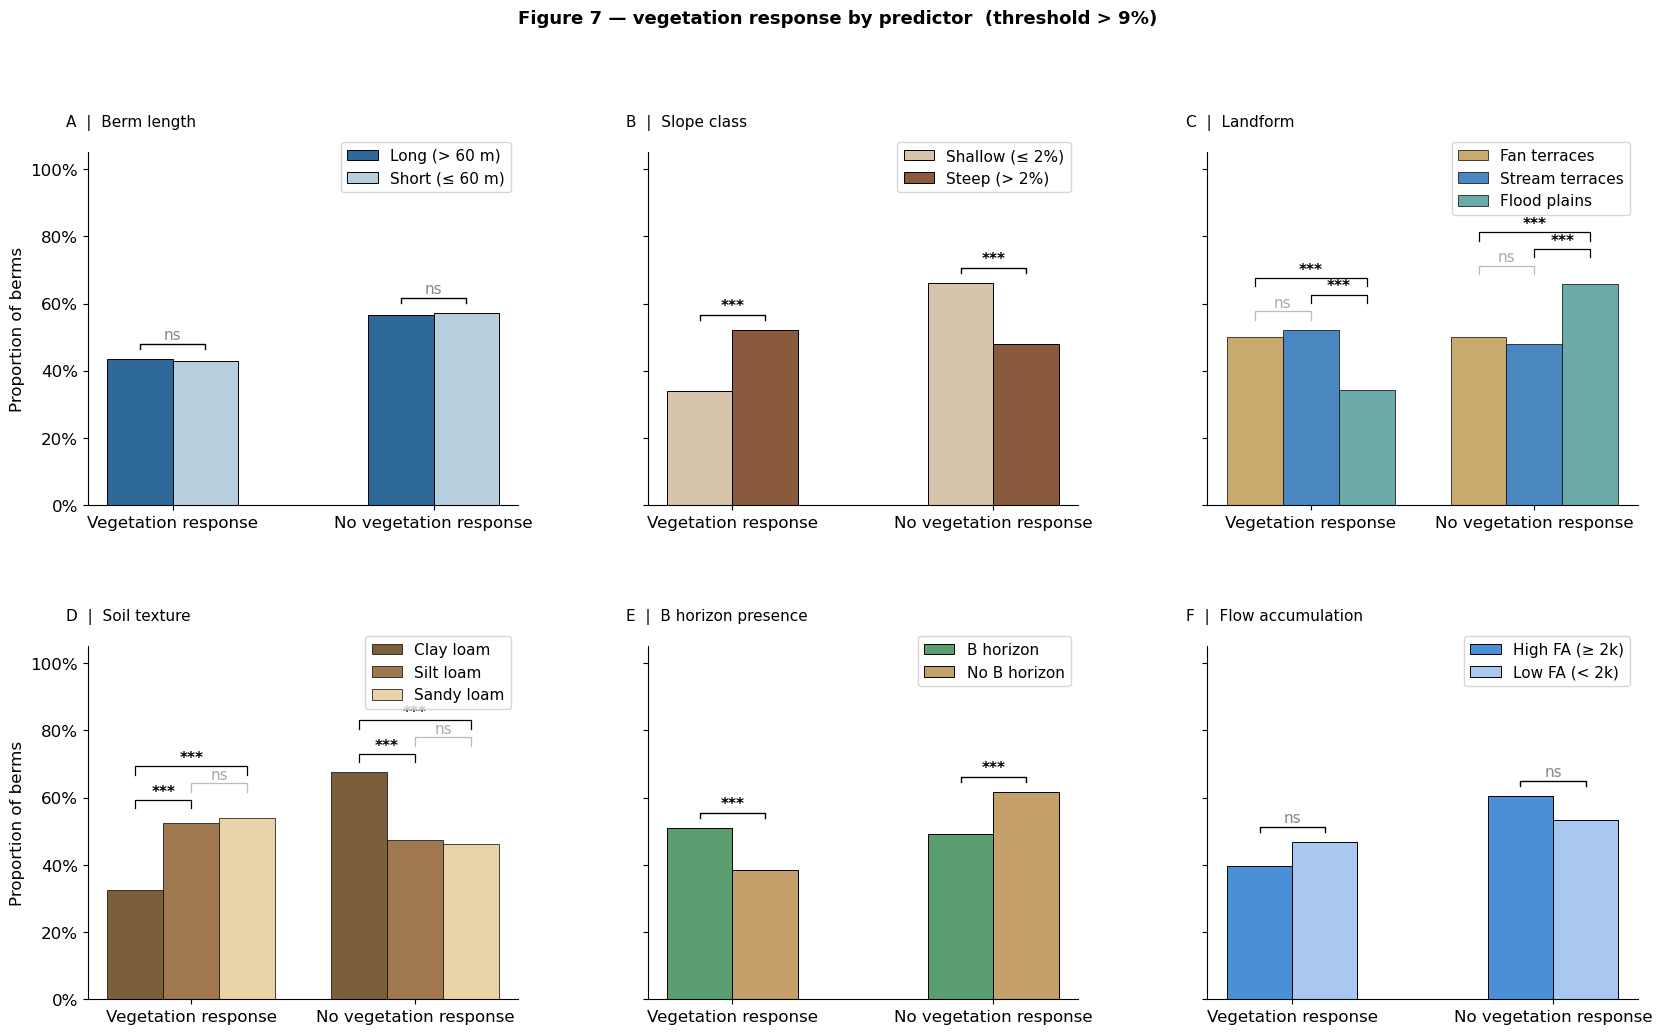

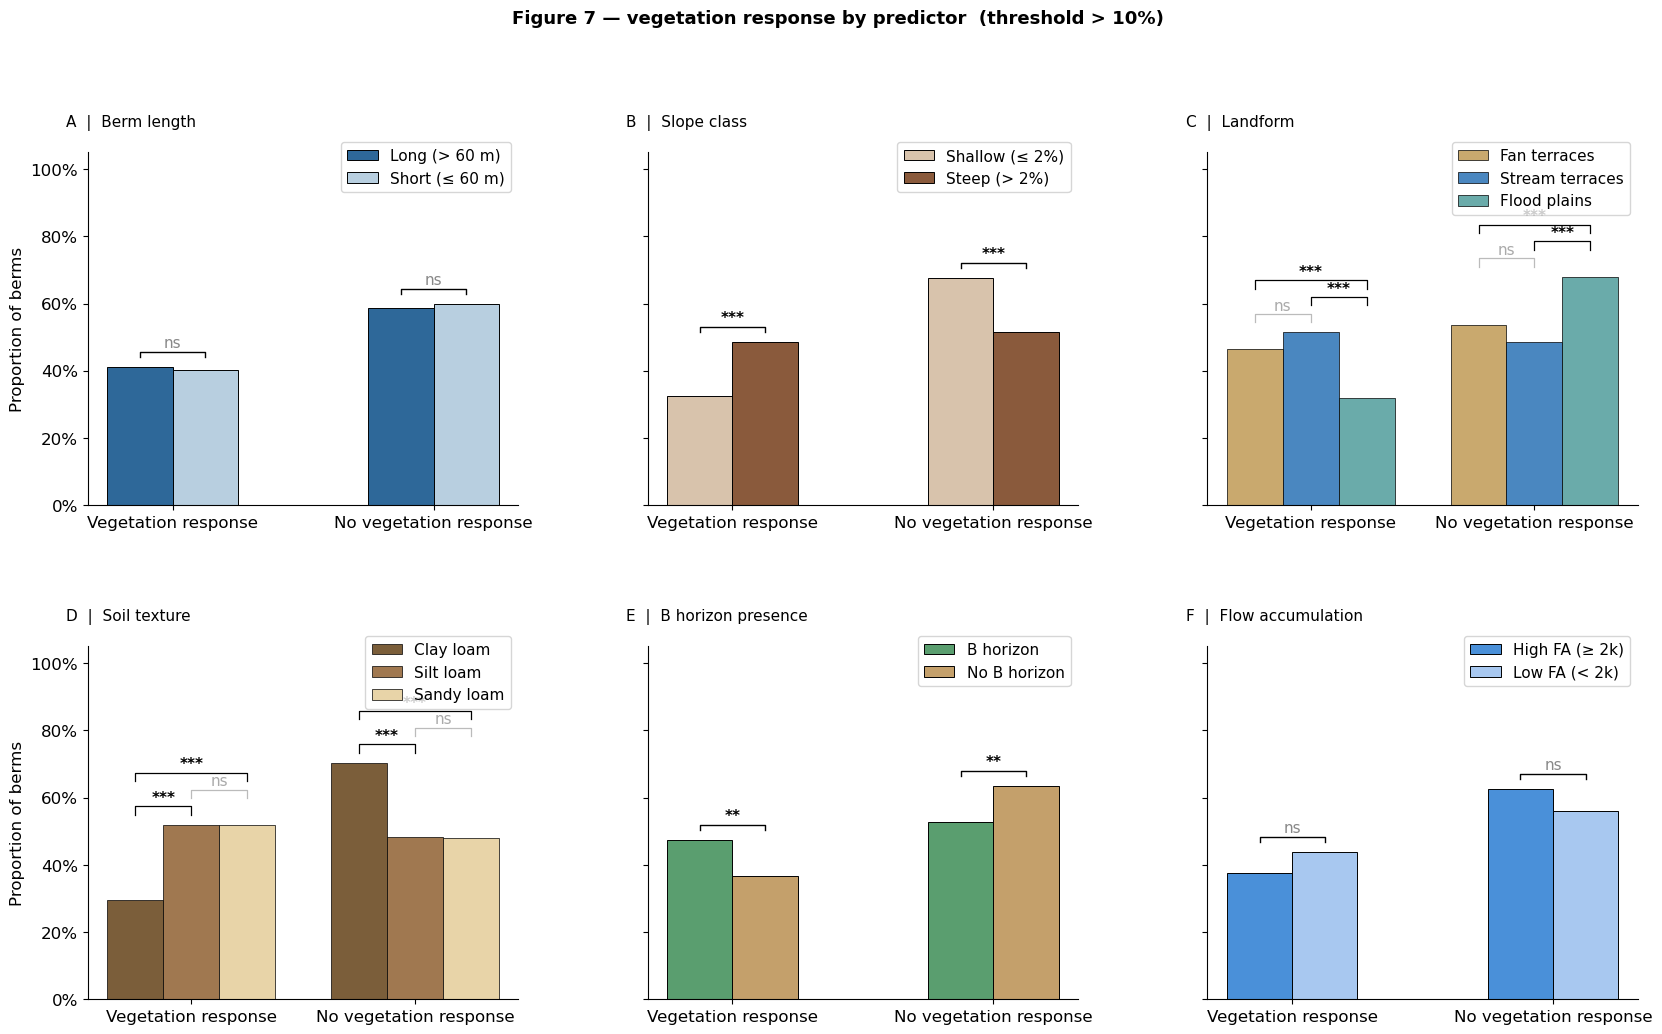

Saved 11 renders to ../figures/sensitivity/


In [6]:
for t in THRESHOLDS:
    fig = draw_fig7(data, t, save=True)
    plt.show()
    plt.close(fig)
print(f"Saved {len(THRESHOLDS)} renders to {SENS_DIR}/")